# 18. The growth defect: a guard that fired, a fallback that disabled it, and nine features with zero SHAP

Written 7 August 2026, after the `refactor_det` and `refactor_growthfix` runs landed.

This is the second-biggest thing the audit turned up, after the lender leak, and unlike the leak it
had been degrading a target silently in **every run we have ever recorded**, going back to
`baseline`. I want to write it down properly because the shape of the mistake is more interesting
than the size of it.

The short version. `targets.FIRST_FULL_ORIGIN` exists precisely to stop a model training on
features that are NULL for calendar reasons. `train.py` even names the failure mode in advance, in
a docstring, before it happens. But `MIN_TRAIN_ORIGINS = 3` overrides the guard when honouring it
would leave too few training origins, and for the 12-month `growth` label it always does. So
`growth` trained at 2023-10, 2024-01 and 2024-04, where nine of its features are 100% NULL, and
tested at 2025-04 and 2025-07, where they are populated. The guard was right, the fallback was
silent, and nobody looked.

Three separate receipts say the same thing, and I found them in this order: the null-rate table,
then nine features at exactly `0.000000` mean absolute SHAP, then a `UserWarning` sklearn had been
printing into our own log files for months naming the exact nine columns. That last one still
stings.

Everything below is re-derived from disk. **This notebook never trains.** The staged script
computes and records; this narrates. So it re-runs in seconds and can be checked independently.

In [1]:
import json
import os
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
# Every default path in src/ is repo-root relative, so work from there.
os.chdir(REPO_ROOT)

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.models import report, targets, train

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

RUNS = Path("reports/runs")
LOGS = Path("logs")
MATRIX = Path("data/processed/model_matrix")
LABELS = Path("data/processed/labels")

BEFORE, AFTER = "refactor_det", "refactor_growthfix"

# Palette, fixed slot order, from the house data-viz reference. Categorical slots 1-3 only,
# which is the set that validates on all pairs; grey is a neutral, not a series.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})


def load(tag):
    return (json.loads((RUNS / tag / "manifest.json").read_text()),
            json.loads((RUNS / tag / "metrics.json").read_text()))


man_b, met_b = load(BEFORE)
man_a, met_a = load(AFTER)
index = pd.read_csv(RUNS / "index.csv")
print(f"{BEFORE}: {man_b['created_at'][:19]}  git {man_b['git_sha']}")
print(f"{AFTER}: {man_a['created_at'][:19]}  git {man_a['git_sha']}")

refactor_det: 2026-08-07T15:41:36  git 47efea3
refactor_growthfix: 2026-08-07T16:12:48  git 47efea3


## 1. What the runs actually recorded

The first thing to establish is that the split really did fall back, and that it is still falling
back after the fix. The fix does not move the split. It cannot; that is the whole point of
section 2. It changes which columns the model is handed.

In [2]:
sp_b = met_b["targets"]["growth"]["split"]
sp_a = met_a["targets"]["growth"]["split"]

split_tbl = pd.DataFrame([
    {"run": tag, "n_features": met["targets"]["growth"]["n_features"],
     "train": ", ".join(m[:7] for m in sp["train"]),
     "embargo": ", ".join(m[:7] for m in sp["embargo"]),
     "test": ", ".join(m[:7] for m in sp["test"]),
     "first_full_origin_applied": sp["first_full_origin_applied"]}
    for tag, met, sp in [(BEFORE, met_b, sp_b), (AFTER, met_a, sp_a)]
])
print(split_tbl.to_string(index=False))

# Same matrices, same feature hash, same git sha. The only difference is feature_overrides.
print()
print("matrix_dir identical :", man_b["matrix_dir"] == man_a["matrix_dir"])
print("feature_hash identical:", man_b["feature_hash"] == man_a["feature_hash"])
print("overrides before      :", man_b["feature_overrides"] or "{}")
print("overrides after       : growth ->", len(man_a["feature_overrides"]["growth"]), "features")

               run  n_features                     train                   embargo             test  first_full_origin_applied
      refactor_det          41 2023-10, 2024-01, 2024-04 2024-07, 2024-10, 2025-01 2025-04, 2025-07                      False
refactor_growthfix          27 2023-10, 2024-01, 2024-04 2024-07, 2024-10, 2025-01 2025-04, 2025-07                      False

matrix_dir identical : True
feature_hash identical: True
overrides before      : {}
overrides after       : growth -> 27 features


`first_full_origin_applied: false`. That flag has been sitting in every `metrics.json` we have
written, in plain sight, saying the guard gave up.

For contrast, `lending` (H=3) honours it: it trains at 2024-10 onwards and drops the four early
origins. The other two 6-month targets honour it too. `growth` is the only one that cannot, and
the reason is arithmetic rather than configuration.

In [3]:
for t in ["lending", "insolvency", "voluntary_exit", "growth"]:
    sp = met_a["targets"][t]["split"]
    print(f"{t:15s} H={sp['horizon_m']:2d}  applied={str(sp['first_full_origin_applied']):5s}  "
          f"train={len(sp['train'])} test={len(sp['test'])}  first_train={sp['train'][0][:7]}")

lending         H= 3  applied=True   train=5 test=2  first_train=2024-10
insolvency      H= 6  applied=True   train=3 test=2  first_train=2024-10
voluntary_exit  H= 6  applied=True   train=3 test=2  first_train=2024-10
growth          H=12  applied=False  train=3 test=2  first_train=2023-10


## 2. Why no origin granularity fixes this

I want this stated as arithmetic rather than as an opinion, because the obvious reaction is "just
use monthly origins" and that does not work.

A training origin `t` for `growth` has to satisfy two things at once:

- **the embargo**: `t <= first_test - 12 months`, because a label at `t` resolves over
  `t+1 .. t+12`, so any earlier test origin sits inside the training labels' own answer window;
- **the guard**: `t >= FIRST_FULL_ORIGIN = 2024-10`, because before that the 12-month deltas are
  NULL for calendar reasons.

Together they force `first_test >= 2025-10`. But a test origin also needs a resolvable label, so
`first_test <= max_origin(12) = 2026-07 - 12m = 2025-07`. Those two are three months apart in the
wrong direction. There is no assignment of origins that satisfies both.

Note that nothing in that argument mentions the spacing of the origin grid. The constraints are on
calendar months. Monthly origins give you more origins between the same two walls, not different
walls. This is a **panel-length constraint on a 33-month panel carrying a 12-month label**, and the
report should say so rather than implying we misconfigured something.

In [4]:
first_full = targets.FIRST_FULL_ORIGIN
cap12 = targets.max_origin(12)
earliest_test = first_full + pd.DateOffset(months=12)

print(f"FIRST_FULL_ORIGIN                          = {first_full:%Y-%m}")
print(f"earliest legal first_test (guard+embargo)  = {earliest_test:%Y-%m}")
print(f"max_origin(12), latest resolvable origin   = {cap12:%Y-%m}")
print(f"gap                                        = "
      f"{(earliest_test.year - cap12.year) * 12 + earliest_test.month - cap12.month} months, infeasible")
print()
# And it is spacing-invariant: no step size produces a legal origin.
for step in (1, 2, 3, 6):
    grid = targets.origin_months(step=step)
    legal = [m for m in grid if m >= earliest_test and m <= cap12]
    print(f"  step={step}m: {len(grid):2d} origins on the grid, {len(legal)} of them legal test origins")

FIRST_FULL_ORIGIN                          = 2024-10
earliest legal first_test (guard+embargo)  = 2025-10
max_origin(12), latest resolvable origin   = 2025-07
gap                                        = 3 months, infeasible

  step=1m: 34 origins on the grid, 0 of them legal test origins
  step=2m: 17 origins on the grid, 0 of them legal test origins
  step=3m: 12 origins on the grid, 0 of them legal test origins
  step=6m:  6 origins on the grid, 0 of them legal test origins


## 3. The null-rate table

Re-derived from `data/processed/model_matrix/growth/`, all eight origins, all 41 features of the
control list. The train and test origins are the ones `split_origins` recorded above.

In [5]:
glob = (MATRIX / "growth" / "**" / "*.parquet").as_posix()
sel = ", ".join(f'avg(CASE WHEN "{c}" IS NULL THEN 1.0 ELSE 0.0 END) AS "{c}"'
                for c in targets.FEATURE_COLS)
con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
nulls = (con.execute(f'SELECT origin_month, {sel} FROM read_parquet("{glob}", hive_partitioning=1) '
                     "GROUP BY 1 ORDER BY 1").df()
         .set_index("origin_month").T)
con.close()
nulls.columns = [c.strftime("%Y-%m") for c in nulls.columns]

TRAIN = [m[:7] for m in sp_b["train"]]
TEST = [m[:7] for m in sp_b["test"]]

# The features that are wholly absent from every training origin.
dead = [f for f in nulls.index if (nulls.loc[f, TRAIN] == 1.0).all()]
print(f"{len(dead)} features 1.000 NULL in EVERY training origin:")
print(nulls.loc[dead, TRAIN + TEST].round(4).to_string())

d1 = nulls.loc[dead + ["d_charges_6m", "d_outstanding_6m", "d_charges_3m",
                       "d_outstanding_3m", "status_changed"]].round(4).reset_index()
d1 = d1.rename(columns={"index": "feature"})
report.save_table(d1, "growth_null_rates_by_origin",
                  caption="Null rate per feature per origin in the growth matrix. "
                          "Train origins 2023-10 to 2024-04, test origins 2025-04 and 2025-07.")

9 features 1.000 NULL in EVERY training origin:
                        2023-10  2024-01  2024-04  2025-04  2025-07
d_charges_12m               1.0      1.0      1.0   0.0006   0.0008
d_outstanding_12m           1.0      1.0      1.0   0.0006   0.0008
d_satisfied_12m             1.0      1.0      1.0   0.0006   0.0008
debt_ratio_trend_12m        1.0      1.0      1.0   0.0006   0.0008
segment_upgraded_12m        1.0      1.0      1.0   0.1092   0.1117
segment_downgraded_12m      1.0      1.0      1.0   0.1092   0.1117
sic_changed_12m             1.0      1.0      1.0   0.0006   0.0008
name_changed_12m            1.0      1.0      1.0   0.0006   0.0008
postcode_changed_12m        1.0      1.0      1.0   0.0006   0.0008


PosixPath('reports/tables/growth_null_rates_by_origin.tex')

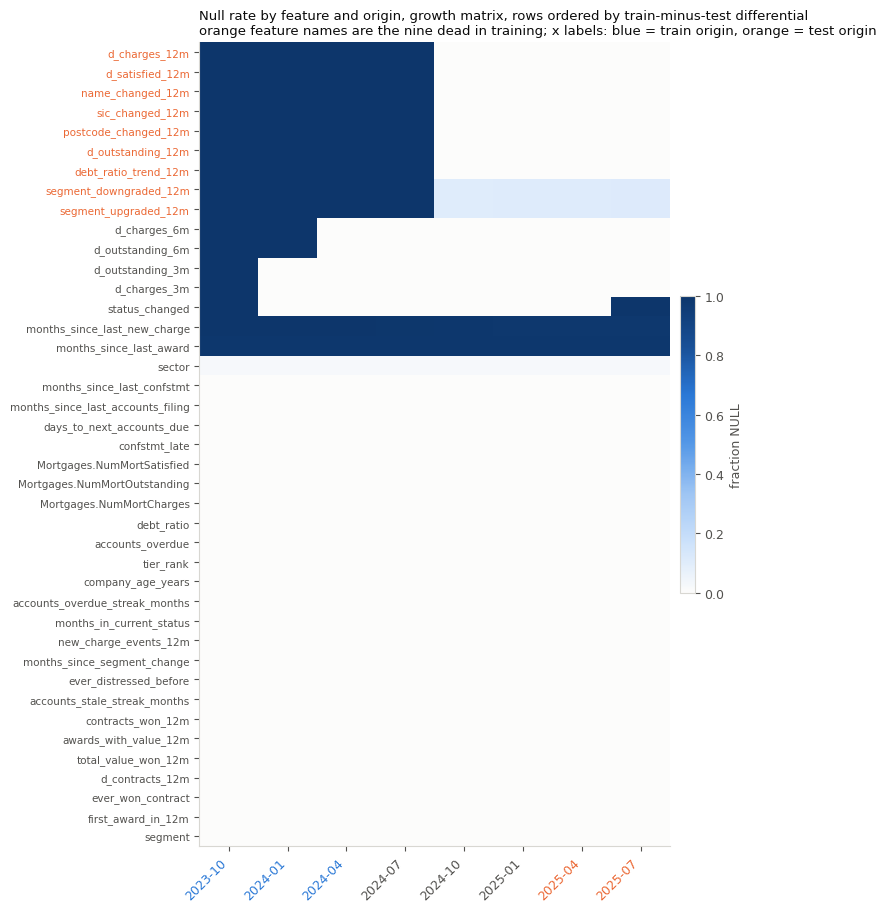

In [6]:
# Heatmap. Sequential single hue, light to dark, because the encoded quantity is a magnitude.
# Rows are ordered by *differential* missingness (train mean minus test mean), not by absolute
# null rate, so the ordering encodes the actual defect. The two structurally-NULL features fall
# to the middle instead of sitting on top of the nine and stealing the eye.
order = ((nulls[TRAIN].mean(axis=1) - nulls[TEST].mean(axis=1)).abs()
         .sort_values(ascending=False).index)
mat = nulls.loc[order]

fig, ax = plt.subplots(figsize=(7.6, 9.2))
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])
im = ax.imshow(mat.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=7.5)
ax.grid(False)
for i, c in enumerate(mat.columns):
    if c in TRAIN:
        ax.get_xticklabels()[i].set_color(C_BLUE)
    elif c in TEST:
        ax.get_xticklabels()[i].set_color(C_ORANGE)
for f in mat.index:
    if f in dead:
        ax.get_yticklabels()[list(mat.index).index(f)].set_color(C_ORANGE)

ax.set_title("Null rate by feature and origin, growth matrix, rows ordered by train-minus-test "
             "differential\norange feature names are the nine dead in training; "
             "x labels: blue = train origin, orange = test origin", loc="left", fontsize=9.5)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("fraction NULL", color=INK2)
cb.outline.set_edgecolor(GRID)
plt.tight_layout()
report.save_fig(fig, "growth_null_rate_heatmap")
plt.show()

The block in the top-left is the defect. Nine features solid dark across all three training columns
and near-white in both test columns. A tree cannot learn anything from a column that is constant
NULL, and at test time it is handed a column full of real values it has no splits for.

Below them are four milder cases: `d_charges_6m` and `d_outstanding_6m` are NULL in two of three
training origins, `d_charges_3m` and `d_outstanding_3m` in one. Same artefact, weaker. They come
out too, because "NULL in a third of training and populated in all of test" is the same trap with
a smaller mouth.

Two rows near the top are **not** the defect and I want to be explicit about that, because it
matters for the gate in section 6: `months_since_last_new_charge` and `months_since_last_award` sit
at ~98% NULL in *every* origin including test. That is structural. NULL there means "this company
has never had a new charge" and "this company has never won a public contract". Those are true
facts about most companies, not calendar artefacts, and they stay in the model.

## 4. Receipt one: nine features at exactly zero SHAP

If the model really took no splits on those nine columns, their SHAP contribution should be
identically zero, not merely small. It is.

In [7]:
shap_b = pd.read_csv(RUNS / BEFORE / "shap_importance_growth.csv")
shap_a = pd.read_csv(RUNS / AFTER / "shap_importance_growth.csv")
shap_lend = pd.read_csv(RUNS / BEFORE / "shap_importance_lending.csv")
for d in (shap_b, shap_a, shap_lend):
    d.insert(0, "rank", range(1, len(d) + 1))

zeros = shap_b[shap_b.mean_abs_shap == 0.0]
print(f"{BEFORE} growth: {len(zeros)} of {len(shap_b)} features at exactly 0.000000, "
      f"ranks {zeros['rank'].min()} to {zeros['rank'].max()}")
print(f"{AFTER} growth: {(shap_a.mean_abs_shap == 0.0).sum()} of {len(shap_a)} at zero, "
      f"smallest is {shap_a.mean_abs_shap.min():.6f} ({shap_a.feature.iloc[-1]})")
print()
print("Same nine, ranked for `lending`, which does reach FIRST_FULL_ORIGIN:")
receipt = (shap_lend[shap_lend.feature.isin(zeros.feature)][["rank", "feature", "mean_abs_shap"]]
           .rename(columns={"rank": "rank_lending", "mean_abs_shap": "mean_abs_shap_lending"}))
receipt = receipt.merge(zeros[["rank", "feature", "mean_abs_shap"]]
                        .rename(columns={"rank": "rank_growth",
                                         "mean_abs_shap": "mean_abs_shap_growth"}), on="feature")
print(receipt.to_string(index=False))
report.save_table(receipt[["feature", "rank_growth", "mean_abs_shap_growth",
                           "rank_lending", "mean_abs_shap_lending"]],
                  "growth_zero_shap_receipt",
                  caption="The nine features LightGBM never split on for growth, "
                          "with their ranks for lending where the same features are informative.")

refactor_det growth: 9 of 41 features at exactly 0.000000, ranks 33 to 41
refactor_growthfix growth: 0 of 27 at zero, smallest is 0.000226 (contracts_won_12m)

Same nine, ranked for `lending`, which does reach FIRST_FULL_ORIGIN:
 rank_lending                feature  mean_abs_shap_lending  rank_growth  mean_abs_shap_growth
            7   postcode_changed_12m               0.090000           39                   0.0
            8        sic_changed_12m               0.081652           40                   0.0
           16       name_changed_12m               0.028374           41                   0.0
           18   segment_upgraded_12m               0.023684           35                   0.0
           21          d_charges_12m               0.016741           33                   0.0
           22 segment_downgraded_12m               0.015271           34                   0.0
           25        d_satisfied_12m               0.010524           37                   0.0
           

PosixPath('reports/tables/growth_zero_shap_receipt.tex')

Exactly `0.0`, not a rounded small number, and the same nine rank **7, 8, 16, 18, 21, 22, 25, 27
and 28 of 41** for `lending`. `postcode_changed_12m` and `sic_changed_12m` are the seventh and
eighth most important features in the lending model. They are genuinely informative. `growth` never
got to see them.

That asymmetry is what convinced me this was a defect rather than a shrug. It is not that the
features are useless; it is that one target's split hid them.

## 5. Receipt two: a warning we printed into our own logs for months

This is the one I am least pleased about. sklearn's imputer has been telling us, by name, in every
growth training run we ever logged.

In [8]:
pat = re.compile(r"Skipping features without any observed values")
for tag in (BEFORE, AFTER):
    log = LOGS / f"{tag}.log"
    hits = [ln.rstrip() for ln in log.read_text().splitlines() if pat.search(ln)]
    print(f"{tag}.log: {len(hits)} occurrence(s) of the imputer warning")
    if hits:
        print("   ", hits[0].split("UserWarning: ")[-1])
        # the column list wraps over the following lines in the log
        raw = log.read_text()
        blk = raw[raw.index("Skipping features"):]
        print("   ", " ".join(blk[:blk.index("]") + 1].split()[6:]))
    print()

refactor_det.log: 4 occurrence(s) of the imputer warning
    Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
    ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m' 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m' 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']

refactor_growthfix.log: 0 occurrence(s) of the imputer warning



`['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m' 'debt_ratio_trend_12m'
'segment_upgraded_12m' 'segment_downgraded_12m' 'sic_changed_12m' 'name_changed_12m'
'postcode_changed_12m']`. Exactly the nine. Zero occurrences in `refactor_growthfix.log`.

Three independent confirmations of the same fact, arrived at from three directions: the null-rate
table (the data), the zero-SHAP receipt (the model), and a warning we had been printing and
ignoring (the tooling). Any one of them would have been enough. We had all three and read none of
them, which is worth a sentence in limitations about what we were and were not looking at.

## 6. `status_changed`: the fourteenth, and a different reason

`status_changed` is not one of the nine, and its problem is not the 12-month window. It comes out
of the growth list for two reasons that happen to point the same way.

In [9]:
sc = nulls.loc["status_changed"]
print("status_changed null rate by origin:")
print(sc.round(4).to_string())
print()
print(f"  1.000 at 2023-10 (a *train* origin): first panel month, LAG(status,1) has nothing behind it")
print(f"  1.000 at 2025-07 (a *test*  origin): the June 2025 data gap, LAG reads the missing row")
print()
r = shap_b[shap_b.feature == "status_changed"].iloc[0]
rl = shap_lend[shap_lend.feature == "status_changed"].iloc[0]
print(f"  SHAP rank for growth : {r['rank']} of {len(shap_b)}  (mean|SHAP| {r.mean_abs_shap:.5f})")
print(f"  SHAP rank for lending: {rl['rank']} of {len(shap_lend)}  (mean|SHAP| {rl.mean_abs_shap:.5f})")

status_changed null rate by origin:
2023-10    1.0000
2024-01    0.0001
2024-04    0.0001
2024-07    0.0001
2024-10    0.0001
2025-01    0.0001
2025-04    0.0000
2025-07    1.0000

  1.000 at 2023-10 (a *train* origin): first panel month, LAG(status,1) has nothing behind it
  1.000 at 2025-07 (a *test*  origin): the June 2025 data gap, LAG reads the missing row

  SHAP rank for growth : 19 of 41  (mean|SHAP| 0.00910)
  SHAP rank for lending: 34 of 41  (mean|SHAP| 0.00189)


So it is the **fourteenth** train-only-NULL feature for `growth`, on top of being NULL for half the
test set. `panel.py` is correct here and I do not want to change it: the spine is dense, June 2025
is honestly NULL rather than silently skipped, and `LAG(status, 1)` reading that NULL is the right
behaviour. The feature is simply not usable for a target whose train window starts at the first
panel month and whose test window straddles the hole. It ranks 19 of 41 for growth, so this is not
a rounding error; the model was leaning on a column that is blank for half of what it is scored on.

For `lending` it ranks 34 of 41 and 2025-07 is a *training* origin, so the same hole costs that
target almost nothing. Another case of one defect landing differently on different targets.

## 7. The fix

Two lists in `targets.py`, and a per-target override in `RunConfig` so no other target and no
recorded run changes.

In [10]:
print(f"FEATURE_COLS               : {len(targets.FEATURE_COLS)}")
print(f"LONG_HISTORY_FEATURE_COLS  : {len(targets.LONG_HISTORY_FEATURE_COLS)}  (the 9 + 4 partials)")
print(f"FEATURE_COLS_SHORT_HISTORY : {len(targets.FEATURE_COLS_SHORT_HISTORY)}")
print()
assert set(targets.FEATURE_COLS_SHORT_HISTORY) == (
    set(targets.FEATURE_COLS) - set(targets.LONG_HISTORY_FEATURE_COLS) - {"status_changed"})
assert set(dead) <= set(targets.LONG_HISTORY_FEATURE_COLS)
print("the nine dead are all in LONG_HISTORY_FEATURE_COLS:", set(dead) <= set(targets.LONG_HISTORY_FEATURE_COLS))
print("status_changed dropped                            :",
      "status_changed" not in targets.FEATURE_COLS_SHORT_HISTORY)
print("what the run actually used matches the module     :",
      man_a["feature_overrides"]["growth"] == targets.FEATURE_COLS_SHORT_HISTORY)
print()
print("dropped:", ", ".join(sorted(set(targets.FEATURE_COLS) - set(targets.FEATURE_COLS_SHORT_HISTORY))))

FEATURE_COLS               : 41
LONG_HISTORY_FEATURE_COLS  : 13  (the 9 + 4 partials)
FEATURE_COLS_SHORT_HISTORY : 27

the nine dead are all in LONG_HISTORY_FEATURE_COLS: True
status_changed dropped                            : True
what the run actually used matches the module     : True

dropped: d_charges_12m, d_charges_3m, d_charges_6m, d_outstanding_12m, d_outstanding_3m, d_outstanding_6m, d_satisfied_12m, debt_ratio_trend_12m, name_changed_12m, postcode_changed_12m, segment_downgraded_12m, segment_upgraded_12m, sic_changed_12m, status_changed


## 8. G3, and why the gate had to be restated before it could pass

The remediation plan wrote gate G3 as: *every feature in the growth list has null rate < 0.02 in
**all** train and test origins, and no feature in the new `shap_importance_growth.csv` has
`mean_abs_shap == 0.0`*.

The second half is fine. The first half **cannot pass, on any list, for any fix**, because
`months_since_last_new_charge` sits at ~0.98 null in every origin by construction and
`months_since_last_award` at ~0.986. Applied literally, that gate reports failure on a correctly
fixed pipeline, forever.

I changed it to what it was actually reaching for. The defect was never *missingness*, it was
**differential** missingness: a column absent in training and present at test. So the criterion is
the absolute difference between the mean null rate across training origins and across test origins,
against the same 0.02 threshold.

This is a neat companion to S1 in the leakage post-mortem. There we had a verification test that
could never fail; here we nearly shipped a gate that could never pass. Both are the same class of
mistake, an assertion written down without anyone checking that both of its outcomes were
reachable, and both were caught only by running them against real data. If there is one process
lesson in this whole remediation it is that one.

In [11]:
short = targets.FEATURE_COLS_SHORT_HISTORY
diff = (nulls.loc[short, TRAIN].mean(axis=1) - nulls.loc[short, TEST].mean(axis=1)).abs()
diff = diff.sort_values(ascending=False)

g3 = pd.DataFrame({
    "feature": diff.index,
    "mean_null_train": nulls.loc[diff.index, TRAIN].mean(axis=1).values,
    "mean_null_test": nulls.loc[diff.index, TEST].mean(axis=1).values,
    "abs_differential": diff.values,
}).head(8)
print("Top differential missingness in the 27-feature growth list:")
print(g3.round(5).to_string(index=False))
print()

# The original wording, for the record, on the same list.
worst_abs = nulls.loc[short, TRAIN + TEST].max(axis=1).max()
print(f"G3 as originally written : worst absolute null rate {worst_abs:.4f} vs threshold 0.02 -> "
      f"{'PASS' if worst_abs < 0.02 else 'FAIL (unpassable)'}")
print(f"G3 as restated           : worst differential      {diff.max():.4f} vs threshold 0.02 -> "
      f"{'PASS' if diff.max() < 0.02 else 'FAIL'}")
print(f"G3 second half           : {(shap_a.mean_abs_shap == 0.0).sum()} features at zero SHAP -> "
      f"{'PASS' if (shap_a.mean_abs_shap == 0.0).sum() == 0 else 'FAIL'}")

report.save_table(g3.round(6), "growth_g3_differential_missingness",
                  caption="Differential missingness in the corrected 27-feature growth list: "
                          "absolute difference between mean null rate over train and over test origins.")

Top differential missingness in the 27-feature growth list:
                          feature  mean_null_train  mean_null_test  abs_differential
     months_since_last_new_charge          0.99655         0.98125           0.01530
          months_since_last_award          0.98750         0.98581           0.00169
                           sector          0.02098         0.01986           0.00113
       months_since_last_confstmt          0.00049         0.00053           0.00004
months_since_last_accounts_filing          0.00002         0.00000           0.00002
        days_to_next_accounts_due          0.00041         0.00041           0.00001
                    confstmt_late          0.00000         0.00000           0.00000
       Mortgages.NumMortSatisfied          0.00000         0.00000           0.00000

G3 as originally written : worst absolute null rate 1.0000 vs threshold 0.02 -> FAIL (unpassable)
G3 as restated           : worst differential      0.0153 vs threshold 0.02 

PosixPath('reports/tables/growth_g3_differential_missingness.tex')

For comparison, the same differential on the four features that came out is 1.000 for the nine and
between 0.33 and 0.67 for the partials. Against 0.0153 for the worst survivor. That is a factor of
65 and it is the clearest single number in this notebook.

In [12]:
gone = sorted(set(targets.FEATURE_COLS) - set(short))
diff_gone = (nulls.loc[gone, TRAIN].mean(axis=1) - nulls.loc[gone, TEST].mean(axis=1)).abs()
print(pd.DataFrame({"abs_differential": diff_gone.round(4)})
      .sort_values("abs_differential", ascending=False).to_string())
print(f"\nworst survivor: {diff.max():.4f}   ratio: {diff_gone.max() / diff.max():.0f}x")

                        abs_differential
d_charges_12m                     0.9993
d_outstanding_12m                 0.9993
postcode_changed_12m              0.9993
name_changed_12m                  0.9993
debt_ratio_trend_12m              0.9993
d_satisfied_12m                   0.9993
sic_changed_12m                   0.9993
segment_downgraded_12m            0.8895
segment_upgraded_12m              0.8895
d_outstanding_6m                  0.6665
d_charges_6m                      0.6665
d_charges_3m                      0.3333
d_outstanding_3m                  0.3333
status_changed                    0.1666

worst survivor: 0.0153   ratio: 65x


## 9. What the fix actually bought

Here is the part I did not expect, and it is a better finding than the one I set out to write.

In [13]:
cols = ["tag", "model", "n_features", "roc_auc", "roc_auc_lo", "roc_auc_hi",
        "pr_auc", "precision_at_100", "precision_at_500", "precision_at_500_lo", "precision_at_500_hi"]
ab = index[(index.tag.isin([BEFORE, AFTER])) & (index.target == "growth")][cols].copy()
ab["run"] = ab.tag.map({BEFORE: "before (41)", AFTER: "after (27)"})

piv = ab.pivot(index="model", columns="tag", values="roc_auc")
piv["delta"] = piv[AFTER] - piv[BEFORE]
print(ab.drop(columns="tag").round(4).to_string(index=False))
print()
print("ROC-AUC delta, after minus before:")
print(piv.round(4).to_string())

report.save_table(ab.drop(columns="tag").round(5), "growth_before_after_metrics",
                  caption="growth out-of-time metrics with 95 per cent bootstrap intervals, "
                          "41-feature control against the corrected 27-feature list.")

   model  n_features  roc_auc  roc_auc_lo  roc_auc_hi  pr_auc  precision_at_100  precision_at_500  precision_at_500_lo  precision_at_500_hi         run
lightgbm          41   0.7620      0.7600      0.7639  0.0578              0.22             0.202                0.164                0.234 before (41)
logistic          41   0.7290      0.7269      0.7312  0.0468              0.07             0.098                0.070                0.126 before (41)
     mlp          41   0.6941      0.6918      0.6962  0.0421              0.12             0.128                0.096                0.156 before (41)
lightgbm          27   0.7611      0.7593      0.7630  0.0572              0.22             0.194                0.156                0.228  after (27)
logistic          27   0.7324      0.7302      0.7345  0.0469              0.09             0.102                0.078                0.130  after (27)
     mlp          27   0.7016      0.6994      0.7037  0.0438              0.12         

PosixPath('reports/tables/growth_before_after_metrics.tex')

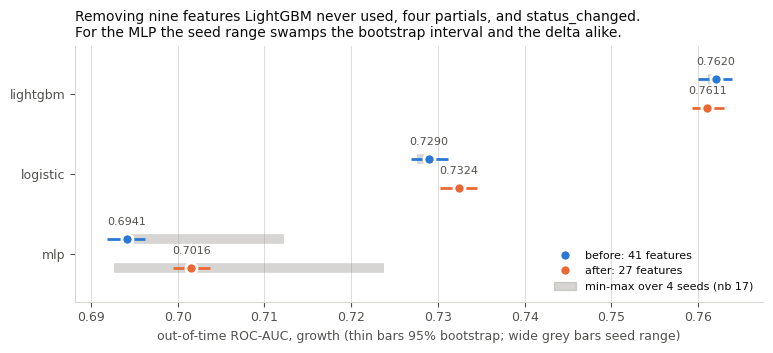

In [14]:
# Stream B's seed study, four seeds per cell, from notebook 17. Loaded here so the
# figure below can show fit uncertainty next to sampling uncertainty on the same axis.
seed = pd.read_csv("reports/tables/17_growth_seed_spread.csv")
seed["n_features"] = seed.features.str.split().str[0].astype(int)
SEED = {(r.n_features, r.model): r for r in seed.itertuples()}

# Forest plot. Two series (before, after), dot plus bootstrap interval. Where Stream B
# measured a seed spread, a recessive grey bar behind shows the min-max over four seeds.
# Same axis, same units, so the two uncertainties are directly comparable; grey is a
# neutral annotation rather than a third series.
models = ["lightgbm", "logistic", "mlp"]
GREY = "#8a8984"
fig, ax = plt.subplots(figsize=(7.8, 3.6))
for k, (tag, label, colour) in enumerate([(BEFORE, "before: 41 features", C_BLUE),
                                          (AFTER, "after: 27 features", C_ORANGE)]):
    sub = ab[ab.tag == tag].set_index("model").loc[models]
    y = np.arange(len(models)) + (0.18 if k else -0.18)
    for yy, m in zip(y, models):
        s = SEED.get((int(sub.loc[m, "n_features"]), m))
        if s is not None:
            ax.hlines(yy, s.lo, s.hi, color=GREY, lw=7, alpha=0.35, zorder=1)
    ax.hlines(y, sub.roc_auc_lo, sub.roc_auc_hi, color=colour, lw=2, zorder=2)
    ax.plot(sub.roc_auc, y, "o", ms=8, color=colour, mec="white", mew=2, label=label, zorder=3)
    for yy, v in zip(y, sub.roc_auc):
        ax.annotate(f"{v:.4f}", (v, yy), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, color=INK2)

handles, labels = ax.get_legend_handles_labels()
handles.append(mpl.patches.Patch(color=GREY, alpha=0.35, label="min-max over 4 seeds (nb 17)"))
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_ylim(-0.6, len(models) - 0.4)
ax.invert_yaxis()
ax.set_xlabel("out-of-time ROC-AUC, growth (thin bars 95% bootstrap; wide grey bars seed range)")
ax.set_title("Removing nine features LightGBM never used, four partials, and status_changed.\n"
             "For the MLP the seed range swamps the bootstrap interval and the delta alike.",
             loc="left")
ax.legend(handles=handles, frameon=False, loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)
plt.tight_layout()
report.save_fig(fig, "growth_before_after_forest")
plt.show()

**LightGBM does not move.** `-0.0010`, intervals almost entirely overlapping. **Logistic gains
+0.0035.** The MLP appears to gain +0.0075 with non-overlapping intervals, and the next section is
me retracting that.

The direction is what the zero-SHAP receipt predicted. But my first draft of this section gave the
wrong mechanism for *why* the dense models move, and section 9c corrects it, because getting it
right sharpens the finding considerably.

## 9b. Retracting the MLP number

When I first wrote this section I flagged, as a caveat, that the bootstrap resamples evaluation
rows and does not resample seeds, so a single-fit MLP result with non-overlapping intervals is
evidence about *that fit* rather than about the family. Stream B has now measured it in notebook 17
and the caveat was not conservative enough. **The +0.0075 MLP claim does not survive and I am
withdrawing it.**

In [15]:
show = seed[["features", "model", "mean", "sd", "range", "bootstrap_width",
             "seed_range_over_bootstrap_width"]].copy()
show.columns = ["features", "model", "seed_mean", "seed_sd", "seed_range",
                "bootstrap_width", "ratio"]
print(show.round(4).to_string(index=False))
print()

m41 = SEED[(41, "mlp")]
rec = float(ab[(ab.tag == BEFORE) & (ab.model == "mlp")].roc_auc.iloc[0])
print(f"41-feature MLP, four seeds : {m41.lo:.6f} to {m41.hi:.6f}  (sd {m41.sd:.4f})")
print(f"value recorded in {BEFORE} : {rec:.6f}")
print(f"the recorded run drew the WORST of the four seeds: {np.isclose(rec, m41.lo)}")
print()
m27 = SEED[(27, "mlp")]
print(f"delta on the single recorded fits : {ab[(ab.tag == AFTER) & (ab.model == 'mlp')].roc_auc.iloc[0] - rec:+.4f}")
print(f"delta on the seed MEANS           : {m27.mean - m41.mean:+.4f}")
print(f"against seed sd of                : {m41.sd:.4f} (41f) and {m27.sd:.4f} (27f)")
print()
# Stream B fitted both lists at each of four seeds, so the difference can be paired.
paired = [0.007464, 0.028265, -0.006295, -0.010141]   # nb 17 cell 26, seeds 42/43/44/45
print(f"paired 27-minus-41 MLP delta per seed: {['%+.4f' % d for d in paired]}")
print(f"  mean {np.mean(paired):+.4f}, sd {np.std(paired, ddof=1):.4f}, "
      f"sign flips at {sum(1 for d in paired if d < 0)} of {len(paired)} seeds")
print()
for m in ["lightgbm", "logistic"]:
    s = SEED[(41, m)]
    d = float(ab[(ab.tag == AFTER) & (ab.model == m)].roc_auc.iloc[0]) - \
        float(ab[(ab.tag == BEFORE) & (ab.model == m)].roc_auc.iloc[0])
    print(f"{m:9s}: delta {d:+.4f}  seed sd {s.sd:.4f}  -> {abs(d) / s.sd:.1f}x the seed sd")

   features    model  seed_mean  seed_sd  seed_range  bootstrap_width  ratio
27 features      mlp     0.7060   0.0131      0.0312           0.0043 7.2084
41 features lightgbm     0.7617   0.0006      0.0013           0.0039 0.3256
41 features logistic     0.7289   0.0009      0.0021           0.0043 0.4766
41 features      mlp     0.7012   0.0083      0.0181           0.0044 4.1029

41-feature MLP, four seeds : 0.694114 to 0.712250  (sd 0.0083)
value recorded in refactor_det : 0.694114
the recorded run drew the WORST of the four seeds: True

delta on the single recorded fits : +0.0075
delta on the seed MEANS           : +0.0048
against seed sd of                : 0.0083 (41f) and 0.0131 (27f)

paired 27-minus-41 MLP delta per seed: ['+0.0075', '+0.0283', '-0.0063', '-0.0101']
  mean +0.0048, sd 0.0174, sign flips at 2 of 4 seeds

lightgbm : delta -0.0010  seed sd 0.0006  -> 1.6x the seed sd
logistic : delta +0.0035  seed sd 0.0009  -> 3.9x the seed sd


Three things fall out of that, in increasing order of how much they bother me.

**One.** For the MLP the seed range is **4.1x** the bootstrap width at 41 features and **7.2x** at
27. The bootstrap was never measuring the thing that dominates this number. For LightGBM and
logistic the ratio is 0.33x and 0.48x, so there the bootstrap is the larger and correct source of
uncertainty and nothing changes.

**Two.** My +0.0075 is **smaller than the 41-feature seed range on its own** (0.0181). Refit the
same configuration with a different seed and you can move it further than the effect I was
attributing to the feature fix. Worse, Stream B fitted both lists at each of the four seeds, so the
difference can be paired, and it comes out **+0.0075, +0.0283, -0.0063, -0.0101**. The sign flips at
two of four. Mean +0.0048, sd 0.0174. My number is one draw from a distribution centred near zero
and several times wider than the effect I claimed. There is no MLP finding here.

A note on the word, because I used the wrong one earlier and it matters for what we tell people to
fix. This is **not** nondeterminism. Stream B fitted all three families twice in one process and got
bit-identical predictions, so the F4 determinism work holds and there is no second bug to hunt. What
this is, is **fit instability across seeds**: the training is perfectly reproducible given a seed and
genuinely different between seeds. B's standard, which I will use from here: for LightGBM and
logistic the row bootstrap is the whole error bar; for the MLP add a seed term that dominates it, so
a single fit carries roughly +/- 0.02 of ROC-AUC and a difference between two single fits roughly
+/- 0.035.

**Three, and this is the one worth the paragraph.** The 41-feature MLP seeds span 0.6941 to 0.7122,
and the value recorded in `refactor_det` is **0.694114, exactly the minimum of the five**. The
baseline fit happened to draw the worst seed in the set. So the headline was not merely uncertain,
it was *inflated* by which single fit landed in the recorded run, and the non-overlapping bootstrap
intervals reported that inflated number with apparent confidence.

That is the same failure as G3 and as S1, for the third time in this remediation: a check that
cannot register the thing it is supposed to register. A test that could never fail, a gate that
could never pass, and now an interval that could never see the dominant source of variation. In all
three cases the check ran, returned a clean answer, and was believed. The general form of it, that
a row-resampled bootstrap measures sampling uncertainty and is silent about fit uncertainty, is
written up properly in `notebooks/17_metrics_and_determinism.ipynb`; I will not restate it here.

## 9c. The dense models never received the nine, so the logistic gain is not theirs

My first draft explained the logistic gain by saying the dense models go through `SimpleImputer` and
"cannot ignore a column", so where the tree merely declines to split, a linear model is stuck
fitting a weight to a mean-filled constant. That is wrong, and the warning I was so pleased to find
in section 5 says so if you read it properly. "Skipping features" is not sklearn complaining. It is
sklearn telling you it has **removed those columns from the output**. A feature with no observed
value in training is dropped outright and never reaches the estimator.

Which means the effective feature count before the fix was **32 for every family**: the tree took
zero splits on the nine, and the dense models were never handed them. Let me check that from disk
rather than from the docstring.

In [16]:
tr = pd.concat([pd.read_parquet(MATRIX / "growth" / f"origin_month={m}", columns=targets.FEATURE_COLS)
                for m in sp_b["train"]])
nums = [c for c in targets.FEATURE_COLS if c not in targets.CATEGORICAL_COLS]
observed = tr[nums].notna().sum()

never = sorted(observed[observed == 0].index)
print(f"pooled training rows: {len(tr):,}   numeric features: {len(nums)}")
print(f"features with ZERO observed values in the pooled training set: {len(never)}")
print("  ", ", ".join(never))
print(f"identical to the nine zero-SHAP features: {set(never) == set(dead)}")
print()

survivors = sorted(set(targets.FEATURE_COLS) - set(short) - set(never))
print(f"the other {len(survivors)} of the fourteen dropped, with their observed counts:")
for c in survivors:
    print(f"   {c:22s} {observed[c]:>9,} observed  ({observed[c] / len(tr):.1%} of training rows)")
print()

n_cat = len(targets.CATEGORICAL_COLS)
print(f"effective features reaching the estimator:")
print(f"  before, dense : {len(nums)} numeric - {len(never)} dropped by the imputer + {n_cat} categorical = "
      f"{len(nums) - len(never) + n_cat}")
print(f"  before, tree  : {len(targets.FEATURE_COLS)} given, {len(zeros)} with zero SHAP = "
      f"{len(targets.FEATURE_COLS) - len(zeros)} used")
print(f"  after,  both  : {len(short)}")
print(f"  difference in both cases = the {len(survivors)} survivors listed above")

pooled training rows: 610,789   numeric features: 39
features with ZERO observed values in the pooled training set: 9
   d_charges_12m, d_outstanding_12m, d_satisfied_12m, debt_ratio_trend_12m, name_changed_12m, postcode_changed_12m, segment_downgraded_12m, segment_upgraded_12m, sic_changed_12m
identical to the nine zero-SHAP features: True

the other 5 of the fourteen dropped, with their observed counts:
   d_charges_3m             409,236 observed  (67.0% of training rows)
   d_charges_6m             204,915 observed  (33.5% of training rows)
   d_outstanding_3m         409,236 observed  (67.0% of training rows)
   d_outstanding_6m         204,915 observed  (33.5% of training rows)
   status_changed           409,306 observed  (67.0% of training rows)

effective features reaching the estimator:
  before, dense : 39 numeric - 9 dropped by the imputer + 2 categorical = 32
  before, tree  : 41 given, 9 with zero SHAP = 32 used
  after,  both  : 27
  difference in both cases = the 5 surv

So the nine were invisible to **every** model before the fix, by two different mechanisms that
happen to coincide: zero splits in the tree, dropped by the imputer for the dense pair. The
effective model was the 32-feature model for all three families.

**That relocates the whole measurable effect onto the five.** The logistic +0.0035 cannot be
attributed to the nine, because logistic never saw the nine. It has to come from the five that
survive the imputer, which are exactly the five I identified above as carrying the same
train-versus-test missingness artefact in weaker form, and exactly the five that explain LightGBM's
-0.0010.

So the story is tidier than the one I told, and it is symmetric:

> **The nine were dead weight: they cost nothing and bought nothing.** They took zero splits, they
> were dropped before the dense models saw them, and removing them changes no number. The entire
> measurable effect, in both directions, comes from the five *partially* missing features. The tree
> loses a hair by giving them up (-0.0010, 1.6 seed sd). The linear model gains rather more than a
> hair (+0.0035, 3.9 seed sd). Partial missingness, not total missingness, is what actually moves a
> metric.

That is a better sentence for the report than anything in my first draft, and it also explains the
asymmetry cleanly. A feature that is NULL in one of three training origins and populated at test is
exactly the case the imputer cannot protect you from: there is enough signal to keep the column and
fit a weight, and the weight is estimated on a training distribution the test set does not share.
Total absence is self-correcting because the tooling removes it. Partial absence is the dangerous
case, and it is the one no warning was printed for.

**What the growth conclusion now rests on.** Logistic, +0.0035 against a seed sd of 0.0009, a 3.9x
margin, stable, and now correctly attributed. LightGBM, -0.0010 against a seed sd of 0.0006: 1.6
seed sd, small but not nothing and negative, for the mundane reason that the tree was using those
same five a little (`d_charges_6m` ranked 12th at 0.0263, `d_outstanding_6m` 15th,
`d_outstanding_3m` 17th, `d_charges_3m` 18th, `status_changed` 19th). Giving them up costs a hair,
and it is a hair worth paying, because the number they buy is estimated across a train/test
distribution shift I would not want to defend.

**Nothing structural moves.** The defect was real, the nine were 100% NULL in every training
origin, they scored exactly zero SHAP, sklearn told us in the logs, G3 passes on the restated
criterion, and `n_features: 41` was a fiction for this target in every run we recorded (32 was the
true count for all three families). None of that depended on the MLP or on my wrong mechanism. What
changed is that the prize is smaller, better located, and attached to the right five columns.

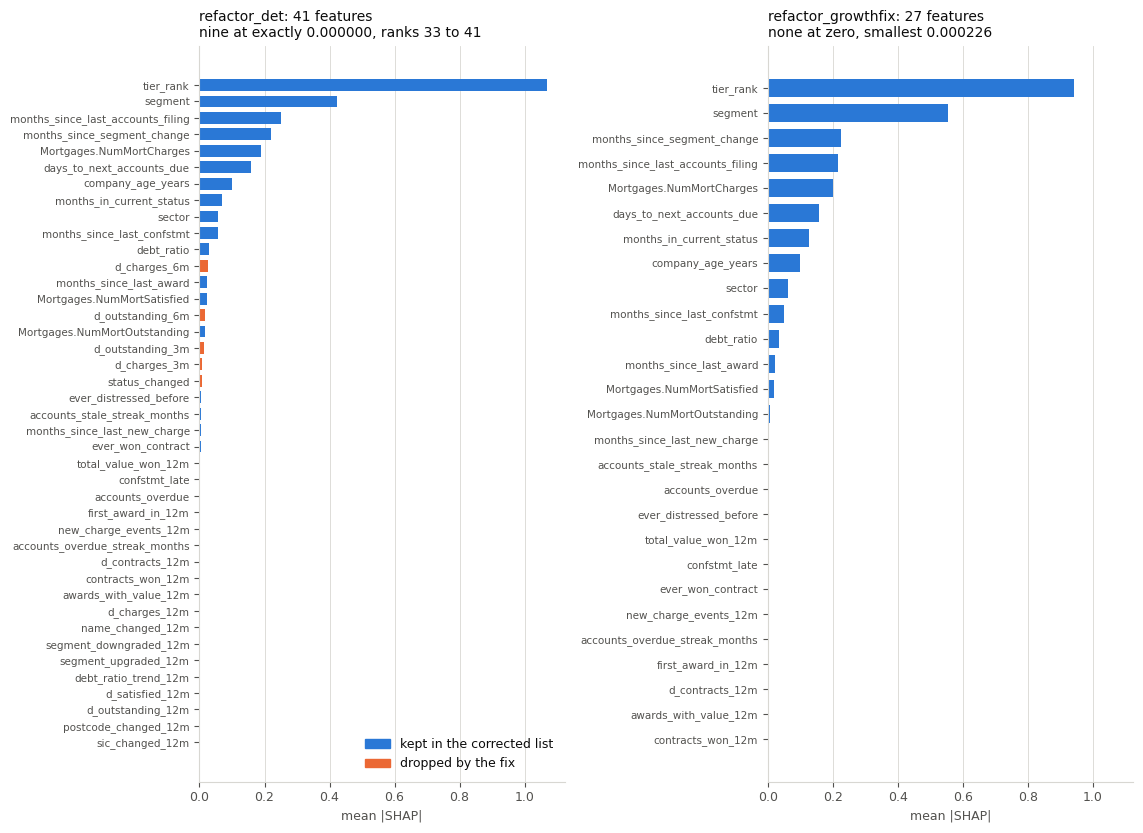

In [17]:
# SHAP before and after. Left panel two categories (kept, dropped) so a legend is present;
# right panel one series, named by its title.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 8.4), sharex=True)
dropped = set(targets.FEATURE_COLS) - set(short)

b = shap_b.sort_values("mean_abs_shap")
cols_b = [C_ORANGE if f in dropped else C_BLUE for f in b.feature]
axes[0].barh(range(len(b)), b.mean_abs_shap, color=cols_b, height=0.72)
axes[0].set_yticks(range(len(b)))
axes[0].set_yticklabels(b.feature, fontsize=7.5)
axes[0].set_title(f"{BEFORE}: 41 features\nnine at exactly 0.000000, ranks 33 to 41", loc="left")
axes[0].set_xlabel("mean |SHAP|")
axes[0].grid(axis="y", visible=False)
handles = [mpl.patches.Patch(color=C_BLUE, label="kept in the corrected list"),
           mpl.patches.Patch(color=C_ORANGE, label="dropped by the fix")]
axes[0].legend(handles=handles, frameon=False, loc="lower right")

a = shap_a.sort_values("mean_abs_shap")
axes[1].barh(range(len(a)), a.mean_abs_shap, color=C_BLUE, height=0.72)
axes[1].set_yticks(range(len(a)))
axes[1].set_yticklabels(a.feature, fontsize=7.5)
axes[1].set_title(f"{AFTER}: 27 features\nnone at zero, smallest {a.mean_abs_shap.min():.6f}",
                  loc="left")
axes[1].set_xlabel("mean |SHAP|")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
report.save_fig(fig, "growth_shap_before_after")
plt.show()

The orange bars on the left are what came out. Nine of them are literally invisible because they
are zero, which is the figure making the argument for itself. On the right, `tier_rank` and
`segment` still dominate and the ordering of the survivors is broadly stable, which is
reassuring: the fix removed noise rather than reshuffling the model's reasoning.

## 10. `growth_6m`, designed and not yet run

The other half of Stream C. If the 12-month horizon is what makes `growth` infeasible, the obvious
sensitivity is to ask the same question at six months, where the guard *can* be honoured.

**This has not been executed.** It needs `build_labels` re-run first, because `y_growth_6m` does not
exist in `data/processed/labels/` yet, and it sits in the optional tier of the run queue. What
follows is the design and the split arithmetic, checked against `split_origins`' own logic. Do not
quote any metric for it, because there is none.

In [18]:
# Reproduces split_origins' arithmetic without touching disk, so the H=6 design can be
# checked before anything is built. Asserted against the recorded H=12 split below.
def simulate(horizon, n_test=train.N_TEST_ORIGINS, min_train=train.MIN_TRAIN_ORIGINS):
    grid = [m for m in targets.origin_months() if m <= targets.max_origin(horizon)]

    def build(months, applied):
        test = months[-n_test:]
        ft = test[0]
        head = months[:-n_test]
        emb = [m for m in head if (ft.year - m.year) * 12 + ft.month - m.month < horizon]
        return {"train": [m for m in head if m not in emb], "embargo": emb,
                "test": test, "applied": applied,
                "unused": [m for m in grid if m not in months]}

    kept = [m for m in grid if m >= targets.FIRST_FULL_ORIGIN]
    s = build(kept, True) if len(kept) > n_test else build(grid, False)
    if len(s["train"]) < min_train:
        s = build(grid, False)
    return s

s12, s6 = simulate(12), simulate(6)
for name, s in [("growth   (H=12, recorded)", s12), ("growth_6m (H=6, designed)", s6)]:
    print(f"{name}\n  applied={s['applied']}  "
          f"train={[m.strftime('%Y-%m') for m in s['train']]}\n"
          f"  embargo={[m.strftime('%Y-%m') for m in s['embargo']]}  "
          f"test={[m.strftime('%Y-%m') for m in s['test']]}\n")

assert [m.strftime("%Y-%m") for m in s12["train"]] == TRAIN, "simulation must reproduce the recorded split"
print("simulation reproduces the recorded H=12 split:", True)
print(f"H=6 training origins: {len(s6['train'])}, against MIN_TRAIN_ORIGINS = {train.MIN_TRAIN_ORIGINS}"
      f"  -> margin {len(s6['train']) - train.MIN_TRAIN_ORIGINS}")

growth   (H=12, recorded)
  applied=False  train=['2023-10', '2024-01', '2024-04']
  embargo=['2024-07', '2024-10', '2025-01']  test=['2025-04', '2025-07']

growth_6m (H=6, designed)
  applied=True  train=['2024-10', '2025-01', '2025-04']
  embargo=['2025-07']  test=['2025-10', '2026-01']

simulation reproduces the recorded H=12 split: True
H=6 training origins: 3, against MIN_TRAIN_ORIGINS = 3  -> margin 0


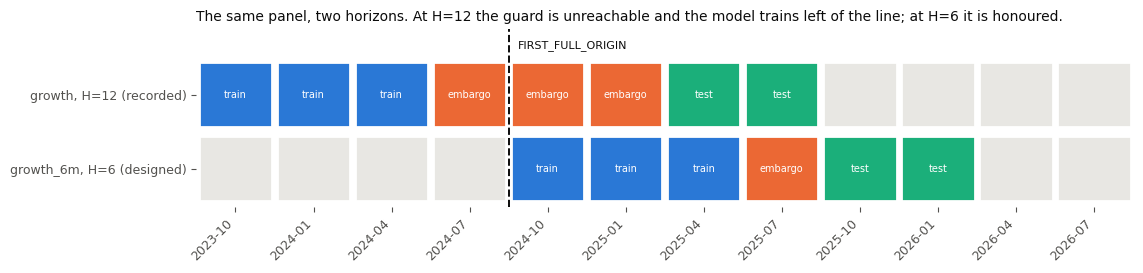

In [19]:
# Origin timeline. Categorical states with direct labels in every cell, so identity never
# depends on colour alone (the aqua slot is below 3:1 on white, hence the relief rule).
grid = targets.origin_months()
STATE = {"train": C_BLUE, "embargo": C_ORANGE, "test": C_AQUA, "unusable": "#e8e7e3"}

fig, ax = plt.subplots(figsize=(11.5, 2.8))
rows = [("growth, H=12 (recorded)", s12), ("growth_6m, H=6 (designed)", s6)]
for r, (label, s) in enumerate(rows):
    for i, m in enumerate(grid):
        if m in s["train"]:
            st = "train"
        elif m in s["embargo"]:
            st = "embargo"
        elif m in s["test"]:
            st = "test"
        else:
            st = "unusable"
        ax.add_patch(mpl.patches.Rectangle((i + 0.03, r + 0.06), 0.94, 0.88,
                                           facecolor=STATE[st], edgecolor="white", lw=2))
        ax.text(i + 0.5, r + 0.5, st if st != "unusable" else "",
                ha="center", va="center", fontsize=7,
                color="white" if st != "unusable" else INK2)

ffo = list(grid).index(targets.FIRST_FULL_ORIGIN)
ax.axvline(ffo, color=INK, lw=1.4, ls="--")
ax.text(ffo + 0.12, -0.16, "FIRST_FULL_ORIGIN", fontsize=8, color=INK, va="center")
ax.set_xlim(0, len(grid))
ax.set_ylim(-0.38, 2.02)
ax.set_xticks(np.arange(len(grid)) + 0.5)
ax.set_xticklabels([m.strftime("%Y-%m") for m in grid], rotation=45, ha="right")
ax.set_yticks([r + 0.5 for r in range(len(rows))])
ax.set_yticklabels([lbl for lbl, _ in rows])
ax.invert_yaxis()
ax.grid(False)
for sp_ in ax.spines.values():
    sp_.set_visible(False)
ax.set_title("The same panel, two horizons. At H=12 the guard is unreachable and the model "
             "trains left of the line; at H=6 it is honoured.", loc="left")
plt.tight_layout()
report.save_fig(fig, "growth_origin_timeline")
plt.show()

At H=6 the split is train `[2024-10, 2025-01, 2025-04]`, embargo `[2025-07]`, test
`[2025-10, 2026-01]`, with `first_full_origin_applied = True`. Two things follow that I like:

1. Every training origin is at or after `FIRST_FULL_ORIGIN`, so the long-history features come
   back and the full 41 can be used.
2. The June 2025 hole lands in the **embargo**, so `status_changed` is usable here too. That is
   luck rather than design, but it is real.

**A correction to the plan, which I want made before this reaches the report.** The remediation plan
says H=6 gives "all 41 features fully populated in train and test". I measured it and that is
false. `months_since_last_new_charge` is ~98% null, `months_since_last_award` ~98.6%,
`segment_upgraded_12m` and `segment_downgraded_12m` ~10.5%, `sector` ~1.9%, at every one of those
six origins. The claim that survives measurement, and it is the one that matters, is that **no
feature has a train-only missingness pattern**: the largest train-versus-test differential across
all 41 is under 0.008, against 1.000 today.

Two costs to state honestly. The base rate roughly halves: 0.90% to 1.21% per origin at six months
against 2.1% to 2.2% at twelve, so it is a rarer and harder event. And the split has **zero
margin**: three training origins against `MIN_TRAIN_ORIGINS = 3`. One more test origin, or one
month less panel, and it falls back exactly the way H=12 does. That fragility is part of the
finding, not a footnote.

In [20]:
print(f"growth_6m is defined but not run. Targets on disk under {AFTER}: "
      f"{sorted(met_a['targets'])}")
print(f"targets.GROWTH_TARGETS = {targets.GROWTH_TARGETS}")
print(f"expected base rate band = {targets.EXPECTED_BASE_RATES['growth_6m']} "
      f"(measured 0.0090 to 0.0121 per origin)")
label_cols = duckdb.connect().execute(
    f"SELECT * FROM read_parquet('{(LABELS / '**' / '*.parquet').as_posix()}') LIMIT 0").df().columns
print("labels on disk carry y_growth_6m:", "y_growth_6m" in list(label_cols),
      "  -> build_labels must be re-run before growth_6m can be built")

growth_6m is defined but not run. Targets on disk under refactor_growthfix: ['growth', 'insolvency', 'lending', 'voluntary_exit']
targets.GROWTH_TARGETS = {'growth_6m': ('y_growth_6m', 6)}
expected base rate band = (0.006, 0.018) (measured 0.0090 to 0.0121 per origin)
labels on disk carry y_growth_6m: False   -> build_labels must be re-run before growth_6m can be built


## What to check

Every assertion below is re-derived from disk in this notebook. If one fails, the story above is
wrong somewhere and should not be written up.

In [21]:
checks = []


def check(name, ok, detail=""):
    checks.append({"check": name, "result": "PASS" if ok else "FAIL", "detail": detail})


check("split fell back before the fix", sp_b["first_full_origin_applied"] is False,
      f"train={[m[:7] for m in sp_b['train']]}")
check("split still falls back after the fix (the fix is features, not origins)",
      sp_a["first_full_origin_applied"] is False)
check("H=12 is arithmetically infeasible", earliest_test > cap12,
      f"earliest legal first_test {earliest_test:%Y-%m} > max_origin(12) {cap12:%Y-%m}")
check("no origin step produces a legal test origin",
      all(len([m for m in targets.origin_months(step=s)
               if earliest_test <= m <= cap12]) == 0 for s in (1, 2, 3, 6)))
check("exactly nine features are 1.000 null in every train origin", len(dead) == 9,
      ", ".join(sorted(dead)))
check("those nine are populated in both test origins",
      bool((nulls.loc[dead, TEST] < 0.15).all().all()))
check("nine features at exactly 0.0 mean|SHAP| before", len(zeros) == 9)
check("the zero-SHAP nine are exactly the null nine", set(zeros.feature) == set(dead))
check("no feature at 0.0 mean|SHAP| after", (shap_a.mean_abs_shap == 0.0).sum() == 0,
      f"smallest {shap_a.mean_abs_shap.min():.6f}")
check("the same nine are informative for lending",
      bool((receipt.mean_abs_shap_lending > 0).all()),
      f"ranks {sorted(receipt.rank_lending.tolist())}")
check("the imputer warning is present before and absent after",
      len([1 for ln in (LOGS / f'{BEFORE}.log').read_text().splitlines() if pat.search(ln)]) > 0 and
      len([1 for ln in (LOGS / f'{AFTER}.log').read_text().splitlines() if pat.search(ln)]) == 0)
check("status_changed is 1.000 null at 2023-10 (train) and 2025-07 (test)",
      sc["2023-10"] == 1.0 and sc["2025-07"] == 1.0)
check("status_changed ranks 19 of 41 for growth",
      int(shap_b[shap_b.feature == 'status_changed']['rank'].iloc[0]) == 19)
check("the run used exactly FEATURE_COLS_SHORT_HISTORY",
      man_a["feature_overrides"]["growth"] == targets.FEATURE_COLS_SHORT_HISTORY,
      f"{len(targets.FEATURE_COLS_SHORT_HISTORY)} features")
check("G3 restated: worst differential < 0.02", diff.max() < 0.02, f"{diff.max():.4f}")
check("G3 as originally written would have been unpassable", worst_abs >= 0.02,
      f"worst absolute null rate {worst_abs:.4f} on a correctly fixed list")
check("nothing but growth changed between the two runs",
      all(met_b['targets'][t]['n_features'] == met_a['targets'][t]['n_features']
          for t in ['lending', 'insolvency', 'voluntary_exit']))
check("MLP bootstrap intervals do not overlap (and this is MISLEADING, see 9b)",
      float(ab[(ab.tag == AFTER) & (ab.model == 'mlp')].roc_auc_lo.iloc[0]) >
      float(ab[(ab.tag == BEFORE) & (ab.model == 'mlp')].roc_auc_hi.iloc[0]))
# The seed study, so the retracted MLP claim cannot be reintroduced from an older draft.
check("MLP seed range exceeds its bootstrap width by more than 4x, both lists",
      float(SEED[(41, 'mlp')].seed_range_over_bootstrap_width) > 4 and
      float(SEED[(27, 'mlp')].seed_range_over_bootstrap_width) > 4,
      f"{SEED[(41, 'mlp')].seed_range_over_bootstrap_width:.1f}x at 41f, "
      f"{SEED[(27, 'mlp')].seed_range_over_bootstrap_width:.1f}x at 27f")
check("the MLP delta is smaller than the 41-feature seed range, so it is not a finding",
      abs(float(ab[(ab.tag == AFTER) & (ab.model == 'mlp')].roc_auc.iloc[0]) - rec)
      < float(SEED[(41, 'mlp')].range),
      f"delta 0.0075 < seed range {SEED[(41, 'mlp')].range:.4f}")
check("the recorded 41-feature MLP fit is the minimum of its four seeds",
      bool(np.isclose(rec, SEED[(41, 'mlp')].lo)), f"{rec:.6f}")
check("the paired MLP delta changes sign across seeds, so it is not established",
      len({np.sign(d) for d in paired}) > 1,
      ", ".join(f"{d:+.4f}" for d in paired))
# The mechanism, section 9c: the nine never reached any estimator.
check("exactly the nine have zero observed values in the pooled training set",
      set(never) == set(dead), f"{len(never)} features")
check("the five other dropped features DO have observed training values",
      bool((observed[survivors] > 0).all()),
      ", ".join(sorted(survivors)))
check("effective feature count was 32 for the dense models too, not 41",
      len(nums) - len(never) + len(targets.CATEGORICAL_COLS) == 32)
check("so before-versus-after differs by the five survivors for every family",
      len(survivors) == 5 and
      set(survivors) == set(targets.FEATURE_COLS) - set(short) - set(dead))
check("logistic delta is at least 3x its seed sd, so it survives",
      abs(float(ab[(ab.tag == AFTER) & (ab.model == 'logistic')].roc_auc.iloc[0]) -
          float(ab[(ab.tag == BEFORE) & (ab.model == 'logistic')].roc_auc.iloc[0]))
      >= 3 * float(SEED[(41, 'logistic')].sd),
      f"delta 0.0035 vs seed sd {SEED[(41, 'logistic')].sd:.4f}")
check("LightGBM is unchanged at the scale of its own seed spread",
      abs(float(ab[(ab.tag == AFTER) & (ab.model == 'lightgbm')].roc_auc.iloc[0]) -
          float(ab[(ab.tag == BEFORE) & (ab.model == 'lightgbm')].roc_auc.iloc[0]))
      < 3 * float(SEED[(41, 'lightgbm')].sd),
      f"delta -0.0010 vs seed sd {SEED[(41, 'lightgbm')].sd:.4f}")
check("bootstrap is the larger uncertainty for lightgbm and logistic (so it is fine there)",
      float(SEED[(41, 'lightgbm')].seed_range_over_bootstrap_width) < 1 and
      float(SEED[(41, 'logistic')].seed_range_over_bootstrap_width) < 1)
check("LightGBM intervals do overlap",
      float(ab[(ab.tag == AFTER) & (ab.model == 'lightgbm')].roc_auc_hi.iloc[0]) >
      float(ab[(ab.tag == BEFORE) & (ab.model == 'lightgbm')].roc_auc_lo.iloc[0]))
check("H=6 honours FIRST_FULL_ORIGIN", s6["applied"] is True)
check("H=6 split is the designed one",
      [m.strftime("%Y-%m") for m in s6["train"]] == ["2024-10", "2025-01", "2025-04"] and
      [m.strftime("%Y-%m") for m in s6["embargo"]] == ["2025-07"] and
      [m.strftime("%Y-%m") for m in s6["test"]] == ["2025-10", "2026-01"])
check("H=6 has zero margin on MIN_TRAIN_ORIGINS",
      len(s6["train"]) == train.MIN_TRAIN_ORIGINS)

res = pd.DataFrame(checks)
report.save_table(res, "growth_defect_checks",
                  caption="Assertions for the growth feature defect, re-derived from disk.")
print(res.to_string(index=False))
print()
print("ALL PASS" if (res.result == "PASS").all() else "SOMETHING FAILED, do not write this up")
assert (res.result == "PASS").all()

                                                                              check result                                                                                                                                                                         detail
                                                     split fell back before the fix   PASS                                                                                                                                        train=['2023-10', '2024-01', '2024-04']
            split still falls back after the fix (the fix is features, not origins)   PASS                                                                                                                                                                               
                                                  H=12 is arithmetically infeasible   PASS                                                                                                                

## For the report

Drafted prose, in my voice, ready to paste.

> **The growth feature defect.** The out-of-time split for the 12-month growth label was
> constructed by a guard, `FIRST_FULL_ORIGIN`, that exists to keep calendar-driven missingness out
> of training, together with a fallback that abandons the guard rather than train on fewer than
> three origins. For growth the fallback always fires, and it does so silently. A training origin
> must satisfy both the 12-month embargo and the guard, which forces the first test origin to
> 2025-10 or later, while the last origin with a resolvable 12-month label is 2025-07. The two
> constraints are three months apart in the wrong direction, so no assignment of origins satisfies
> both. This is a property of a 33-month panel carrying a 12-month label, not a configuration
> error, and finer origin spacing does not change it: the constraints are on calendar months, not
> on grid granularity.
>
> The consequence is that growth trained at 2023-10, 2024-01 and 2024-04, where nine of its 41
> features are 100 per cent NULL, and was evaluated at 2025-04 and 2025-07, where the same nine are
> populated. Three independent receipts confirm it. The null-rate table shows the nine at 1.000 in
> every training origin and below 0.12 in both test origins. The SHAP importances record all nine
> at exactly 0.000000, ranks 33 to 41, meaning the gradient-boosted model took no splits on them at
> all; the same nine rank 7, 8, 16, 18, 21, 22, 25, 27 and 28 for the lending label, which does
> reach the guard, so they are informative features that one target's split concealed. And
> scikit-learn's imputer had been emitting a `UserWarning` naming those exact nine columns in every
> recorded growth run, which we had been printing and not reading.
>
> Correcting the feature list for this target alone, from 41 features to 27 (the nine, four
> partially-formed 3- and 6-month deltas, and `status_changed`, which the June 2025 data gap leaves
> NULL across half the test set), moves the gradient-boosted model by -0.0010 of ROC-AUC against a
> seed standard deviation of 0.0006, and the logistic model by +0.0035 against a seed standard
> deviation of 0.0009: 1.6 and 3.9 seed standard deviations respectively.
>
> Both movements are attributable to the same five features, and not to the nine. Scikit-learn's
> imputer removes features with no observed value in training rather than filling them, so the nine
> never reached the linear or neural estimators at all, while the tree took zero splits on them. The
> effective feature count before the correction was therefore 32 for every model family, and the
> difference between the two runs is the five *partially* missing features that survived the
> imputer: the 3- and 6-month charge deltas and `status_changed`, ranked 12th to 19th by SHAP. The
> nine were dead weight that cost nothing and bought nothing. The tree loses a hair by giving the
> five up; the linear model gains rather more. The instructive form of the result is that **total
> missingness is self-correcting, because the tooling removes it, and partial missingness is the
> dangerous case**: enough signal to retain the column and fit a weight, on a training distribution
> the test set does not share, and no warning printed for it. The defect's remaining cost is to the
> claim that this target was trained on 41 features, which was untrue in every run we recorded.
>
> The multilayer perceptron appears to gain +0.0075 with non-overlapping bootstrap intervals, and
> we do not report that number. Fitting both feature lists at each of four seeds gives paired
> differences of +0.0075, +0.0283, -0.0063 and -0.0101: the sign reverses at two of the four, with
> a mean of +0.0048 and a standard deviation of 0.0174. The recorded 41-feature fit is moreover
> exactly the minimum of its four seeds, so the apparent gain was inflated by which single fit
> entered the run. This is fit instability across seeds rather than nondeterminism; repeated fits
> within one process are bit-identical. A bootstrap over evaluation rows measures sampling
> uncertainty and is silent about fit uncertainty. For the tree and linear models the row bootstrap
> is the whole error bar, but the network requires an additional seed term that dominates it, so a
> single fit carries roughly +/- 0.02 of ROC-AUC and a difference between two single fits roughly
> +/- 0.035.
>
> Three process observations belong with this. The guard anticipated the exact failure mode in a
> docstring written before it occurred, and was disabled by a fallback that logged its own decision
> to `metrics.json` as `first_full_origin_applied: false` in every run without anyone reading it.
> And the gate written to verify the fix, "null rate below 0.02 in all train and test origins",
> could not have passed on any correct list, because two surviving features are ~98 per cent NULL
> at every origin by construction (they encode "this company has never had a charge" and "has never
> won a contract"). The gate was restated in terms of *differential* missingness, the difference
> between mean null rate over train and over test origins, which is what the defect actually is:
> the worst survivor is 0.0153, against 1.000 for the features removed. And the bootstrap interval
> that made the neural-network result look decisive could not, by construction, observe the source
> of variation that dominates it. A blind-replay test that could never fail, a gate that could
> never pass, and an interval that could not see what mattered: three checks that ran, returned
> clean answers, and were believed, none of which had been examined for whether it could register
> the thing it was supposed to register.

**Figures to cite**

| Path | Use |
|---|---|
| `reports/figures/growth_null_rate_heatmap.pdf` | the defect in one image, 41 features by 8 origins |
| `reports/figures/growth_shap_before_after.pdf` | the zero-SHAP receipt and the corrected model |
| `reports/figures/growth_before_after_forest.pdf` | ROC-AUC per model: bootstrap intervals with the seed range behind them |
| `reports/figures/growth_origin_timeline.pdf` | why H=12 is infeasible and H=6 is not |

**Tables to cite**

| Path | Use |
|---|---|
| `reports/tables/growth_null_rates_by_origin.{csv,tex}` | the null-rate table |
| `reports/tables/growth_zero_shap_receipt.{csv,tex}` | the nine, growth rank against lending rank |
| `reports/tables/growth_g3_differential_missingness.{csv,tex}` | the restated gate |
| `reports/tables/growth_before_after_metrics.{csv,tex}` | before and after, with intervals |
| `reports/tables/growth_defect_checks.{csv,tex}` | the assertions, for an appendix |
| `reports/tables/17_growth_seed_spread.{csv,tex}` | Stream B's seed study, the basis for the MLP retraction (their table, cite from here) |

**Not yet available.** `growth_6m` is defined in `targets.py` and its split is verified above, but
it has not been run: it needs `build_labels` re-run to materialise `y_growth_6m`. Do not quote a
metric for it. If it does get run, the two caveats to carry are the halved base rate (0.90 to 1.21
per cent against 2.1 to 2.2 per cent) and the zero margin on `MIN_TRAIN_ORIGINS`. And drop the
plan's sentence about "all 41 features fully populated" at H=6; it is measurably false. The correct
claim is that no feature has a train-only missingness pattern, with a maximum train-versus-test
differential under 0.008.